# DSC291 HW2: Stochastic Optimization Methods

This notebook implements:
- Part I: Stochastic Subgradient Method for LAD (Model B)
- Part II: SGD variants for Logistic Regression (Model A)
- Part III: SVRG for Logistic Regression (Model A)


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
import os

# Create figures directory
FIG_DIR = "../Figures/hw2"
os.makedirs(FIG_DIR, exist_ok=True)

# Set random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
print(f"Random seed: {RANDOM_SEED}")

# Load and split data
X, y = load_diabetes(return_X_y=True)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_SEED
)

# Normalize features: standardize to mean 0, std 1
# Compute statistics on training set only, then apply to both train and val
X_train_mean = np.mean(X_train, axis=0)
X_train_std = np.std(X_train, axis=0)
# Avoid division by zero
X_train_std = np.where(X_train_std == 0, 1.0, X_train_std)

X_train = (X_train - X_train_mean) / X_train_std
X_val = (X_val - X_train_mean) / X_train_std

n_train, d = X_train.shape
n_val = X_val.shape[0]
print(f"Training samples: {n_train}, Validation samples: {n_val}, Features: {d}")

# Normalize targets for LAD model (keep original y for logistic labels)
y_train_mean = np.mean(y_train)
y_train_std = np.std(y_train)
y_train_std = 1.0 if y_train_std == 0 else y_train_std

y_train_lad = (y_train - y_train_mean) / y_train_std
y_val_lad = (y_val - y_train_mean) / y_train_std

print(f"y_train (raw) stats: mean = {np.mean(y_train):.4f}, std = {np.std(y_train):.4f}, "
      f"min = {np.min(y_train):.4f}, max = {np.max(y_train):.4f}")
print(f"y_val   (raw) stats: mean = {np.mean(y_val):.4f}, std = {np.std(y_val):.4f}, "
      f"min = {np.min(y_val):.4f}, max = {np.max(y_val):.4f}")


Random seed: 42
Training samples: 331, Validation samples: 111, Features: 10
y_train (raw) stats: mean = 154.3444, std = 77.7472, min = 25.0000, max = 346.0000
y_val   (raw) stats: mean = 145.5405, std = 74.3619, min = 37.0000, max = 310.0000


## Model Definitions

### Model A: ℓ₂-Regularized Logistic Regression
### Model B: Least Absolute Deviation (LAD)


In [5]:
# Model A: Logistic Regression
def convert_to_binary_labels(y):
    """Convert responses to binary labels {-1, 1}"""
    median = np.median(y)
    return np.where(y >= median, 1, -1)

y_train_binary = convert_to_binary_labels(y_train)
y_val_binary = convert_to_binary_labels(y_val)

def logistic_loss_i(w, x_i, y_i, lam):
    """f_i(w) = log(1 + exp(-y_i * x_i^T w)) + (λ/2) * ||w||^2"""
    z = y_i * (x_i @ w)
    return np.log(1 + np.exp(-z)) + 0.5 * lam * np.linalg.norm(w)**2

def logistic_loss_full(X, y, w, lam):
    """F(w) = (1/n) * sum_i f_i(w)"""
    n = X.shape[0]
    total = 0.0
    for i in range(n):
        total += logistic_loss_i(w, X[i], y[i], lam)
    return total / n

def logistic_grad_i(w, x_i, y_i, lam):
    """Gradient of f_i(w)"""
    z = y_i * (x_i @ w)
    sigmoid = 1 / (1 + np.exp(z))
    return -y_i * sigmoid * x_i + lam * w

def logistic_grad_batch(X, y, w, lam, indices):
    """Mini-batch gradient"""
    b = len(indices)
    grad = np.zeros_like(w)
    for idx in indices:
        grad += logistic_grad_i(w, X[idx], y[idx], lam)
    return grad / b

# Model B: LAD
def lad_loss_i(w, x_i, y_i):
    """f_i(w) = |x_i^T w - y_i|"""
    return np.abs(x_i @ w - y_i)

def lad_loss_full(X, y, w):
    """F(w) = (1/n) * sum_i |x_i^T w - y_i|"""
    n = X.shape[0]
    total = 0.0
    for i in range(n):
        total += lad_loss_i(w, X[i], y[i])
    return total / n

def lad_subgrad_i(w, x_i, y_i):
    """Subgradient: sign(x_i^T w - y_i) * x_i"""
    residual = x_i @ w - y_i
    if residual == 0:
        # At non-differentiable point, return a subgradient (e.g., 0)
        return np.zeros_like(x_i)
    return np.sign(residual) * x_i


## Part I: Stochastic Subgradient Method for Model B (LAD)


In [6]:
def stochastic_subgradient_lad(X_train, y_train, X_val, y_val, 
                                step_size_schedule, num_iters, 
                                w0=None, seed=42, verbose=False):
    """
    Stochastic subgradient method for LAD.
    
    step_size_schedule: function(k) -> eta_k
    """
    rng = np.random.default_rng(seed)
    n_train = X_train.shape[0]
    d = X_train.shape[1]
    w = np.zeros(d) if w0 is None else w0.copy()
    
    iterations = []
    grad_evals = []
    train_losses = []
    val_losses = []
    
    for k in range(num_iters):
        # Record current state
        iterations.append(k)
        grad_evals.append(k)  # One gradient evaluation per iteration
        train_losses.append(lad_loss_full(X_train, y_train, w))
        val_losses.append(lad_loss_full(X_val, y_val, w))
        
        # Sample random index
        i_k = rng.integers(0, n_train)
        
        # Compute step size
        eta_k = step_size_schedule(k)
        
        # Update
        g_i = lad_subgrad_i(w, X_train[i_k], y_train[i_k])
        w_old = w.copy()
        w = w - eta_k * g_i
        
        # Debug output for first few iterations
        if verbose and k < 5:
            print(f"  Iter {k}: eta={eta_k:.6f}, ||g||={np.linalg.norm(g_i):.4f}, "
                  f"||w_change||={np.linalg.norm(w - w_old):.6f}, loss={train_losses[-1]:.4f}")
    
    # Record final state
    iterations.append(num_iters)
    grad_evals.append(num_iters)
    train_losses.append(lad_loss_full(X_train, y_train, w))
    val_losses.append(lad_loss_full(X_val, y_val, w))
    
    return np.array(iterations), np.array(grad_evals), \
           np.array(train_losses), np.array(val_losses), w

# Define step size schedules
def constant_schedule(eta):
    return lambda k: eta

def sqrt_schedule(eta0):
    return lambda k: eta0 / np.sqrt(k + 1)

def linear_schedule(eta0):
    return lambda k: eta0 / (k + 1)


In [ ]:
# Run experiments for Part I
num_iters_lad = 2000

# With normalized features, step sizes can be more standard
# Estimate appropriate step size based on data scale
max_feature_norm = np.max(np.linalg.norm(X_train, axis=1))
eta0_lad = 0.01
print(f"Estimated max feature norm (after normalization): {max_feature_norm:.4f}")
print(f"Using eta0 = {eta0_lad:.4f} for decaying schedules")

schedules = {
    'Constant (η=0.01)': constant_schedule(0.01),
    'Constant (η=0.001)': constant_schedule(0.001),
    '1/√(k+1)': sqrt_schedule(eta0_lad),
    '1/(k+1)': linear_schedule(eta0_lad)
}

# Check initial loss
w_init = np.zeros(d)
initial_train_loss = lad_loss_full(X_train, y_train_lad, w_init)
initial_val_loss = lad_loss_full(X_val, y_val_lad, w_init)
print(f"\nInitial loss (w=0): train = {initial_train_loss:.4f}, val = {initial_val_loss:.4f}")

# Check a sample subgradient to verify computation
test_idx = 0
test_residual = X_train[test_idx] @ w_init - y_train_lad[test_idx]
test_subgrad = lad_subgrad_i(w_init, X_train[test_idx], y_train_lad[test_idx])
print(f"Sample subgradient norm: {np.linalg.norm(test_subgrad):.4f}")
print(f"Sample residual: {test_residual:.4f}\n")

results_lad = {}
for name, schedule in schedules.items():
    print(f"\nRunning {name}...")
    iters, grad_evals, train_loss, val_loss, w_final = \
        stochastic_subgradient_lad(
            X_train, y_train_lad, X_val, y_val_lad,
            schedule, num_iters_lad, seed=RANDOM_SEED, verbose=True
        )
    results_lad[name] = {
        'iters': iters,
        'grad_evals': grad_evals,
        'train_loss': train_loss,
        'val_loss': val_loss,
        'w_final': w_final
    }
    improvement = initial_train_loss - train_loss[-1]
    print(f"{name}: Final train loss = {train_loss[-1]:.4f}, Final val loss = {val_loss[-1]:.4f}, "
          f"Improvement = {improvement:.4f}, ||w_final|| = {np.linalg.norm(w_final):.4f}")


Estimated max feature norm (after normalization): 6.8667
Using eta0 = 0.0100 for decaying schedules

Initial loss (w=0): train = 0.8515, val = 0.8428
Sample subgradient norm: 2.7863
Sample residual: -0.1499


Running Constant (η=0.01)...
  Iter 0: eta=0.010000, ||g||=3.7584, ||w_change||=0.037584, loss=0.8515
  Iter 1: eta=0.010000, ||g||=1.7909, ||w_change||=0.017909, loss=0.8274
  Iter 2: eta=0.010000, ||g||=3.9508, ||w_change||=0.039508, loss=0.8206
  Iter 3: eta=0.010000, ||g||=2.9215, ||w_change||=0.029215, loss=0.7944
  Iter 4: eta=0.010000, ||g||=2.4822, ||w_change||=0.024822, loss=0.8076
Constant (η=0.01): Final train loss = 0.5846, Final val loss = 0.5925, Improvement = 0.2669, ||w_final|| = 0.6107

Running Constant (η=0.001)...
  Iter 0: eta=0.001000, ||g||=3.7584, ||w_change||=0.003758, loss=0.8515
  Iter 1: eta=0.001000, ||g||=1.7909, ||w_change||=0.001791, loss=0.8489
  Iter 2: eta=0.001000, ||g||=3.9508, ||w_change||=0.003951, loss=0.8482
  Iter 3: eta=0.001000, ||g||=2.9

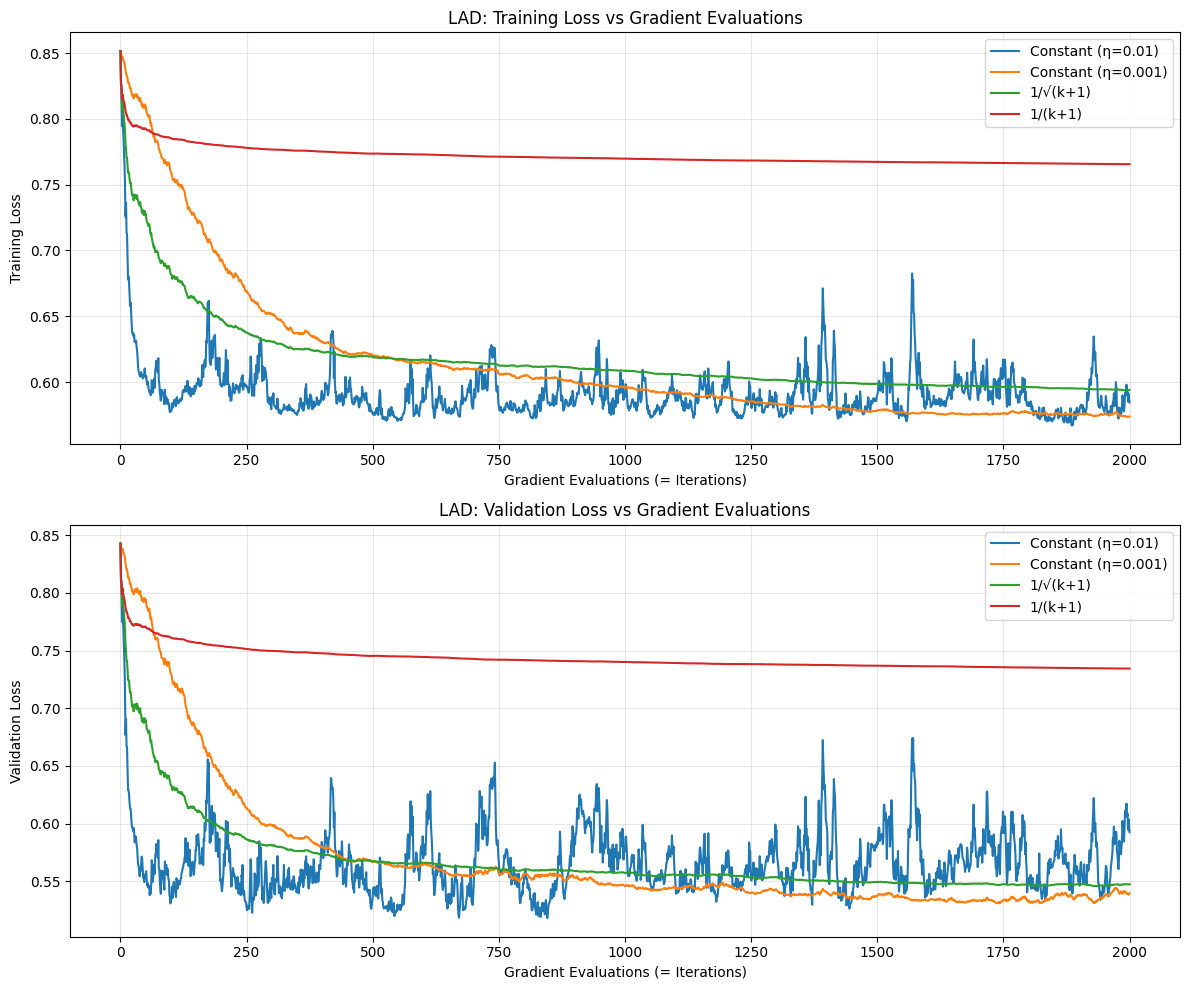

In [ ]:
# Plot Part I results
# Note: For stochastic subgradient method, gradient evaluations = iterations (one per step)
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Training loss vs gradient evaluations
ax = axes[0]
for name, res in results_lad.items():
    ax.plot(res['grad_evals'], res['train_loss'], label=name)
ax.set_xlabel('Gradient Evaluations (= Iterations)')
ax.set_ylabel('Training Loss')
ax.set_title('LAD: Training Loss vs Gradient Evaluations')
ax.legend()
ax.grid(True, alpha=0.3)

# Validation loss vs gradient evaluations
ax = axes[1]
for name, res in results_lad.items():
    ax.plot(res['grad_evals'], res['val_loss'], label=name)
ax.set_xlabel('Gradient Evaluations (= Iterations)')
ax.set_ylabel('Validation Loss')
ax.set_title('LAD: Validation Loss vs Gradient Evaluations')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/part1_lad_subgradient.png', dpi=150, bbox_inches='tight')
plt.show()


## Part II: SGD for Model A (Logistic Regression)

### Part II(a): Mini-batch SGD


In [7]:
def mini_batch_sgd_logistic(X_train, y_train, X_val, y_val, lam, eta, 
                             batch_size, grad_eval_budget, w0=None, 
                             seed=42, averaging=False):
    """
    Mini-batch SGD for logistic regression.
    
    grad_eval_budget: approximate number of gradient evaluations to use
    averaging: if True, return uniform average of iterates
    """
    rng = np.random.default_rng(seed)
    n_train = X_train.shape[0]
    d = X_train.shape[1]
    w = np.zeros(d) if w0 is None else w0.copy()
    w_bar = np.zeros_like(w)  # For averaging
    
    grad_evals = []
    train_losses = []
    val_losses = []
    used = 0
    t = 0
    
    while used < grad_eval_budget:
        # Record current state
        w_plot = w_bar if (averaging and t > 0) else w
        grad_evals.append(used)
        train_losses.append(logistic_loss_full(X_train, y_train, w_plot, lam))
        val_losses.append(logistic_loss_full(X_val, y_val, w_plot, lam))
        
        if used >= grad_eval_budget:
            break
        
        # Sample mini-batch
        indices = rng.choice(n_train, size=batch_size, replace=False)
        
        # Compute gradient and update
        grad = logistic_grad_batch(X_train, y_train, w, lam, indices)
        w = w - eta * grad
        
        # Update average
        if averaging:
            w_bar = (t * w_bar + w) / (t + 1)
        
        used += batch_size
        t += 1
    
    # Final record
    w_plot = w_bar if (averaging and t > 0) else w
    grad_evals.append(used)
    train_losses.append(logistic_loss_full(X_train, y_train, w_plot, lam))
    val_losses.append(logistic_loss_full(X_val, y_val, w_plot, lam))
    
    return np.array(grad_evals), np.array(train_losses), \
           np.array(val_losses), w, w_bar

# Compute smoothness parameter L for Model A
lam = 0.01
L = np.linalg.norm(X_train, 2)**2 / n_train + lam
print(f"λ = {lam}, Estimated L = {L:.4f}")

# Run mini-batch SGD experiments
eta_sgd = 0.1 / L  # Step size
grad_eval_budget = 5000
batch_sizes = [1, 5, 20, 100, n_train]

results_minibatch = {}
for b in batch_sizes:
    grad_evals, train_loss, val_loss, w_final, _ = \
        mini_batch_sgd_logistic(
            X_train, y_train_binary, X_val, y_val_binary,
            lam, eta_sgd, b, grad_eval_budget, seed=RANDOM_SEED
        )
    results_minibatch[b] = {
        'grad_evals': grad_evals,
        'train_loss': train_loss,
        'val_loss': val_loss,
        'w_final': w_final
    }
    print(f"Batch size {b}: Final train loss = {train_loss[-1]:.4f}, "
          f"Final val loss = {val_loss[-1]:.4f}")


λ = 0.01, Estimated L = 3.9288
Batch size 1: Final train loss = 0.5021, Final val loss = 0.5307
Batch size 5: Final train loss = 0.4981, Final val loss = 0.5099
Batch size 20: Final train loss = 0.5115, Final val loss = 0.5163
Batch size 100: Final train loss = 0.5711, Final val loss = 0.5592
Batch size 331: Final train loss = 0.6297, Final val loss = 0.6230


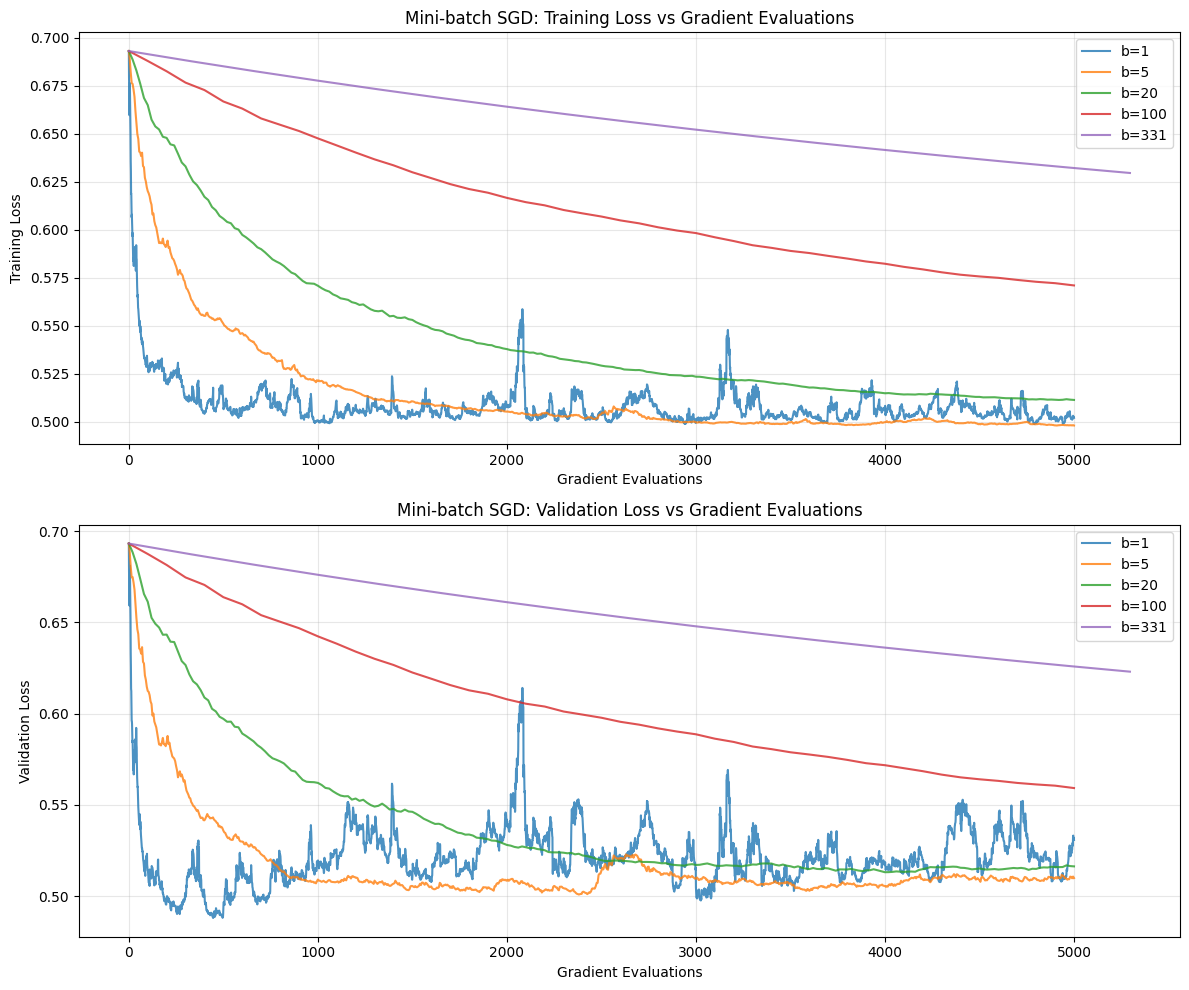

In [12]:
# Plot Part II(a) results
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Training loss vs gradient evaluations
ax = axes[0]
for b, res in results_minibatch.items():
    ax.plot(res['grad_evals'], res['train_loss'], label=f'b={b}', alpha=0.8)
ax.set_xlabel('Gradient Evaluations')
ax.set_ylabel('Training Loss')
ax.set_title('Mini-batch SGD: Training Loss vs Gradient Evaluations')
ax.legend()
ax.grid(True, alpha=0.3)

# Validation loss vs gradient evaluations
ax = axes[1]
for b, res in results_minibatch.items():
    ax.plot(res['grad_evals'], res['val_loss'], label=f'b={b}', alpha=0.8)
ax.set_xlabel('Gradient Evaluations')
ax.set_ylabel('Validation Loss')
ax.set_title('Mini-batch SGD: Validation Loss vs Gradient Evaluations')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/part2a_minibatch_sgd.png', dpi=150, bbox_inches='tight')
plt.show()


### Part II(b): Uniform Averaging


Without averaging:
  Final train loss: 0.511454
  Final val loss: 0.516278

With uniform averaging:
  Final train loss: 0.535932
  Final val loss: 0.530910


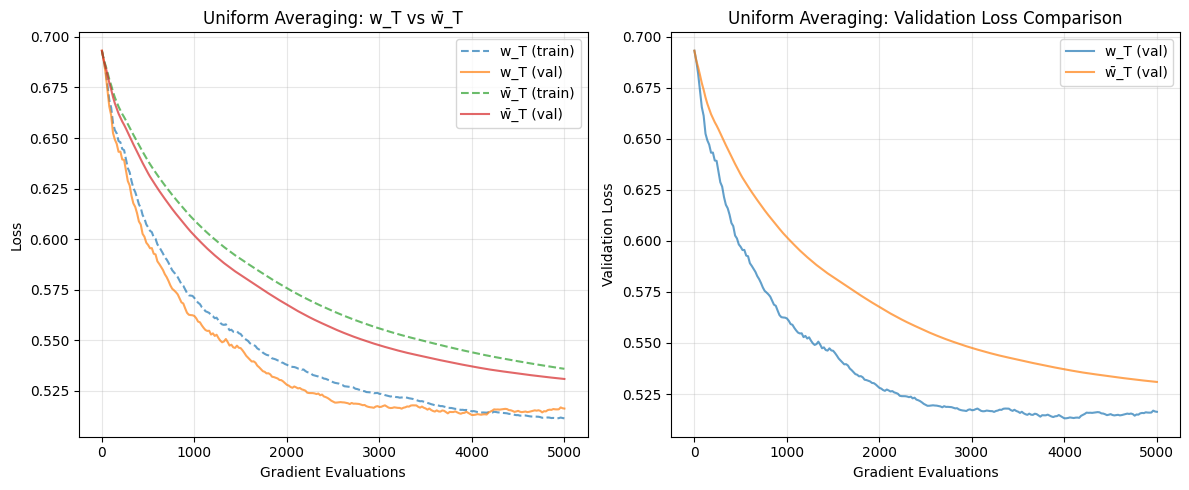

In [13]:
# Compare w_T vs w̄_T (uniform average)
b_avg = 20  # Use batch size 20
grad_eval_budget_avg = 5000

# Without averaging
grad_evals_no_avg, train_loss_no_avg, val_loss_no_avg, w_final_no_avg, _ = \
    mini_batch_sgd_logistic(
        X_train, y_train_binary, X_val, y_val_binary,
        lam, eta_sgd, b_avg, grad_eval_budget_avg, 
        seed=RANDOM_SEED, averaging=False
    )

# With averaging
grad_evals_avg, train_loss_avg, val_loss_avg, w_final_avg, w_bar_final = \
    mini_batch_sgd_logistic(
        X_train, y_train_binary, X_val, y_val_binary,
        lam, eta_sgd, b_avg, grad_eval_budget_avg,
        seed=RANDOM_SEED, averaging=True
    )

print("Without averaging:")
print(f"  Final train loss: {train_loss_no_avg[-1]:.6f}")
print(f"  Final val loss: {val_loss_no_avg[-1]:.6f}")

print("\nWith uniform averaging:")
print(f"  Final train loss: {train_loss_avg[-1]:.6f}")
print(f"  Final val loss: {val_loss_avg[-1]:.6f}")

# Plot comparison
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(grad_evals_no_avg, train_loss_no_avg, 
         label='w_T (train)', linestyle='--', alpha=0.7)
plt.plot(grad_evals_no_avg, val_loss_no_avg, 
         label='w_T (val)', alpha=0.7)
plt.plot(grad_evals_avg, train_loss_avg, 
         label='w̄_T (train)', linestyle='--', alpha=0.7)
plt.plot(grad_evals_avg, val_loss_avg, 
         label='w̄_T (val)', alpha=0.7)
plt.xlabel('Gradient Evaluations')
plt.ylabel('Loss')
plt.title('Uniform Averaging: w_T vs w̄_T')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(grad_evals_no_avg, val_loss_no_avg, 
         label='w_T (val)', alpha=0.7)
plt.plot(grad_evals_avg, val_loss_avg, 
         label='w̄_T (val)', alpha=0.7)
plt.xlabel('Gradient Evaluations')
plt.ylabel('Validation Loss')
plt.title('Uniform Averaging: Validation Loss Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/part2b_uniform_averaging.png', dpi=150, bbox_inches='tight')
plt.show()


### Part II(c): Step Decay with Expanding Epochs


In [9]:
def step_decay_sgd(X_train, y_train, X_val, y_val, lam, 
                   eta0, m0, gamma, batch_size, max_epochs, 
                   w0=None, seed=42):
    """
    Step decay SGD with expanding epochs.
    
    eta0: initial step size
    m0: initial epoch length
    gamma: decay factor (η^(s+1) = γ * η^(s), m^(s+1) = γ^(-1) * m^(s))
    """
    rng = np.random.default_rng(seed)
    n_train = X_train.shape[0]
    d = X_train.shape[1]
    w = np.zeros(d) if w0 is None else w0.copy()
    
    grad_evals = []
    train_losses = []
    val_losses = []
    
    eta_s = eta0
    m_s = int(m0)
    used = 0
    
    for epoch in range(max_epochs):
        # Run m_s iterations with step size eta_s
        for _ in range(m_s):
            # Record state
            grad_evals.append(used)
            train_losses.append(logistic_loss_full(X_train, y_train, w, lam))
            val_losses.append(logistic_loss_full(X_val, y_val, w, lam))
            
            # Sample mini-batch
            indices = rng.choice(n_train, size=batch_size, replace=False)
            
            # Update
            grad = logistic_grad_batch(X_train, y_train, w, lam, indices)
            w = w - eta_s * grad
            
            used += batch_size
        
        # Update step size and epoch length
        eta_s = gamma * eta_s
        m_s = int(m_s / gamma)  # Expanding epochs
        
        if m_s < 1:
            m_s = 1
    
    # Final record
    grad_evals.append(used)
    train_losses.append(logistic_loss_full(X_train, y_train, w, lam))
    val_losses.append(logistic_loss_full(X_val, y_val, w, lam))
    
    return np.array(grad_evals), np.array(train_losses), \
           np.array(val_losses), w

# Run step decay experiments
eta0_decay = 0.1 / L
m0 = 50
batch_size_decay = 20
max_epochs = 5

gammas = [0.5, 0.8]
results_step_decay = {}

# Constant step size baseline
# mini_batch_sgd_logistic returns 5 values: grad_evals, train_loss, val_loss, w, w_bar
grad_evals_const, train_loss_const, val_loss_const, w_const, _ = \
    mini_batch_sgd_logistic(
        X_train, y_train_binary, X_val, y_val_binary,
        lam, eta0_decay, batch_size_decay, 
        grad_eval_budget=5000, seed=RANDOM_SEED
    )
results_step_decay['Constant'] = {
    'grad_evals': grad_evals_const,
    'train_loss': train_loss_const,
    'val_loss': val_loss_const
}

for gamma in gammas:
    grad_evals, train_loss, val_loss, w_final = \
        step_decay_sgd(
            X_train, y_train_binary, X_val, y_val_binary,
            lam, eta0_decay, m0, gamma, batch_size_decay,
            max_epochs, seed=RANDOM_SEED
        )
    results_step_decay[f'γ={gamma}'] = {
        'grad_evals': grad_evals,
        'train_loss': train_loss,
        'val_loss': val_loss
    }
    print(f"γ={gamma}: Final train loss = {train_loss[-1]:.6f}, "
          f"Final val loss = {val_loss[-1]:.6f}")

print(f"\nConstant: Final train loss = {train_loss_const[-1]:.6f}, "
      f"Final val loss = {val_loss_const[-1]:.6f}")



γ=0.5: Final train loss = 0.510677, Final val loss = 0.507966
γ=0.8: Final train loss = 0.511523, Final val loss = 0.510874

Constant: Final train loss = 0.511454, Final val loss = 0.516278


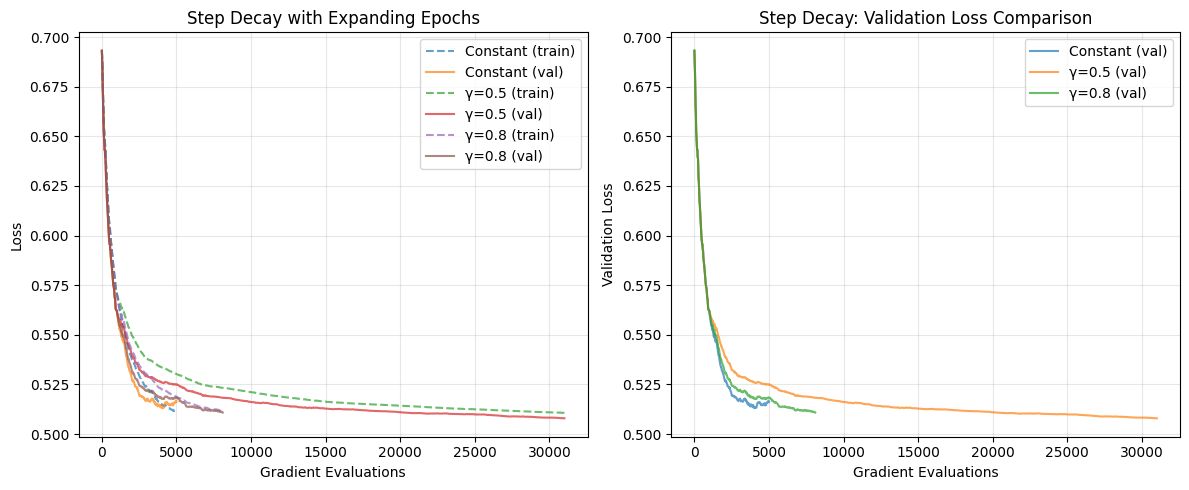

In [10]:
# Plot Part II(c) results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for name, res in results_step_decay.items():
    plt.plot(res['grad_evals'], res['train_loss'], 
             label=f'{name} (train)', linestyle='--', alpha=0.7)
    plt.plot(res['grad_evals'], res['val_loss'], 
             label=f'{name} (val)', alpha=0.7)
plt.xlabel('Gradient Evaluations')
plt.ylabel('Loss')
plt.title('Step Decay with Expanding Epochs')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
for name, res in results_step_decay.items():
    plt.plot(res['grad_evals'], res['val_loss'], 
             label=f'{name} (val)', alpha=0.7)
plt.xlabel('Gradient Evaluations')
plt.ylabel('Validation Loss')
plt.title('Step Decay: Validation Loss Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/part2c_step_decay.png', dpi=150, bbox_inches='tight')
plt.show()


## Part III: SVRG for Model A (Logistic Regression)


In [11]:
def svrg_logistic(X_train, y_train, X_val, y_val, lam, eta, m, 
                  num_epochs, w0=None, seed=42):
    """
    SVRG for logistic regression.
    
    eta: step size
    m: inner loop length
    num_epochs: number of outer epochs
    """
    rng = np.random.default_rng(seed)
    n_train = X_train.shape[0]
    d = X_train.shape[1]
    w = np.zeros(d) if w0 is None else w0.copy()
    w_tilde = w.copy()  # Snapshot
    
    grad_evals = []
    train_losses = []
    val_losses = []
    used = 0
    
    # Record initial state
    grad_evals.append(used)
    train_losses.append(logistic_loss_full(X_train, y_train, w, lam))
    val_losses.append(logistic_loss_full(X_val, y_val, w, lam))
    
    for epoch in range(num_epochs):
        # Compute full gradient at snapshot (costs n gradient evaluations)
        mu_tilde = np.zeros(d)
        for i in range(n_train):
            mu_tilde += logistic_grad_i(w_tilde, X_train[i], y_train[i], lam)
        mu_tilde = mu_tilde / n_train
        used += n_train
        
        # Inner loop
        w0_inner = w_tilde.copy()
        for j in range(m):
            # Sample random index
            i_j = rng.integers(0, n_train)
            
            # Compute variance-reduced gradient
            grad_i_w = logistic_grad_i(w0_inner, X_train[i_j], y_train[i_j], lam)
            grad_i_tilde = logistic_grad_i(w_tilde, X_train[i_j], y_train[i_j], lam)
            v_j = grad_i_w - grad_i_tilde + mu_tilde
            
            # Update
            w0_inner = w0_inner - eta * v_j
            used += 1
            
            # Record periodically
            if j % max(1, m // 10) == 0 or j == m - 1:
                grad_evals.append(used)
                train_losses.append(logistic_loss_full(X_train, y_train, w0_inner, lam))
                val_losses.append(logistic_loss_full(X_val, y_val, w0_inner, lam))
        
        # Update snapshot
        w_tilde = w0_inner.copy()
        w = w0_inner.copy()
    
    return np.array(grad_evals), np.array(train_losses), \
           np.array(val_losses), w

# Compute condition number κ
# For strongly convex function: κ = L / α
# We need to estimate α (strong convexity parameter)
# For logistic regression with ℓ2 regularization: α ≈ λ
alpha = lam
kappa = L / alpha
print(f"Condition number κ = L/α = {kappa:.2f}")

# Run SVRG experiments
eta_options = [0.05 / L, 0.1 / L, 0.2 / L]
m_options = [int(0.5 * kappa), int(kappa), int(2 * kappa)]
num_epochs_svrg = 20

results_svrg = {}
for eta in eta_options:
    for m in m_options:
        name = f'η={eta*L:.2f}/L, m={m}'
        grad_evals, train_loss, val_loss, w_final = \
            svrg_logistic(
                X_train, y_train_binary, X_val, y_val_binary,
                lam, eta, m, num_epochs_svrg, seed=RANDOM_SEED
            )
        results_svrg[name] = {
            'grad_evals': grad_evals,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'w_final': w_final
        }
        print(f"{name}: Final train loss = {train_loss[-1]:.6f}, "
              f"Final val loss = {val_loss[-1]:.6f}")


Condition number κ = L/α = 392.88
η=0.05/L, m=196: Final train loss = 0.497784, Final val loss = 0.508936
η=0.05/L, m=392: Final train loss = 0.497751, Final val loss = 0.509165
η=0.05/L, m=785: Final train loss = 0.497742, Final val loss = 0.508977
η=0.10/L, m=196: Final train loss = 0.497751, Final val loss = 0.509161
η=0.10/L, m=392: Final train loss = 0.497742, Final val loss = 0.508976
η=0.10/L, m=785: Final train loss = 0.497741, Final val loss = 0.508928
η=0.20/L, m=196: Final train loss = 0.497742, Final val loss = 0.508975
η=0.20/L, m=392: Final train loss = 0.497741, Final val loss = 0.508926
η=0.20/L, m=785: Final train loss = 0.497741, Final val loss = 0.508924


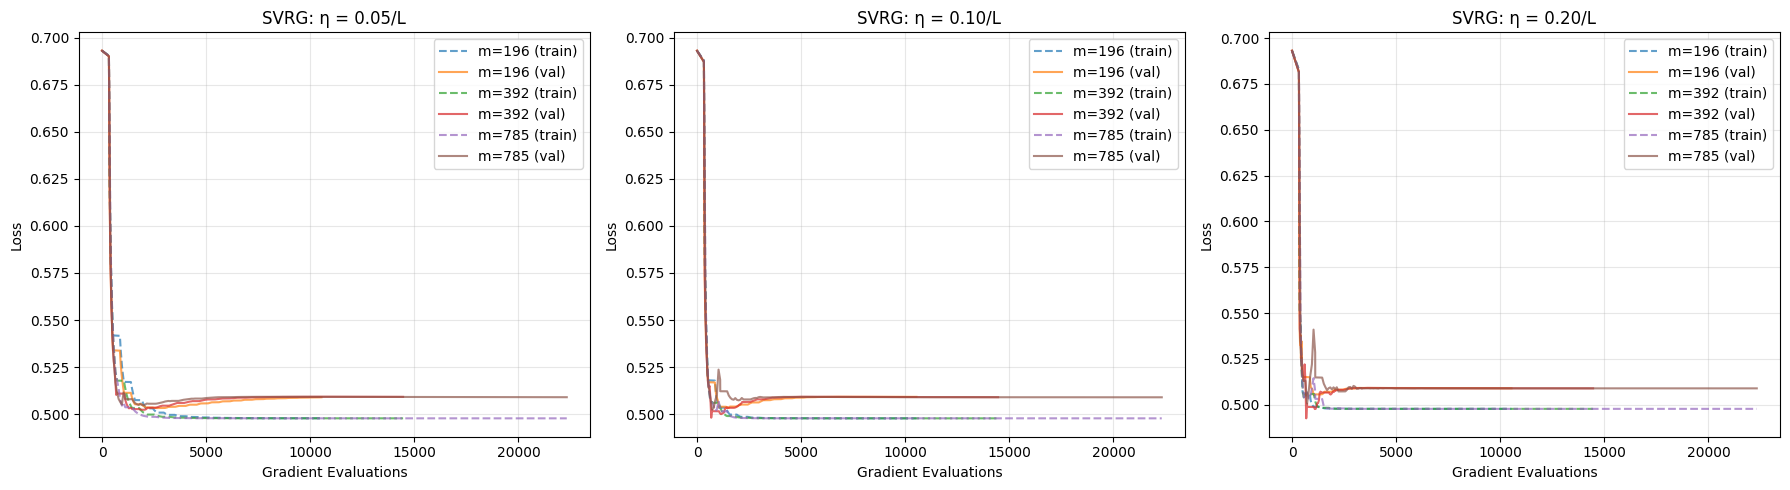

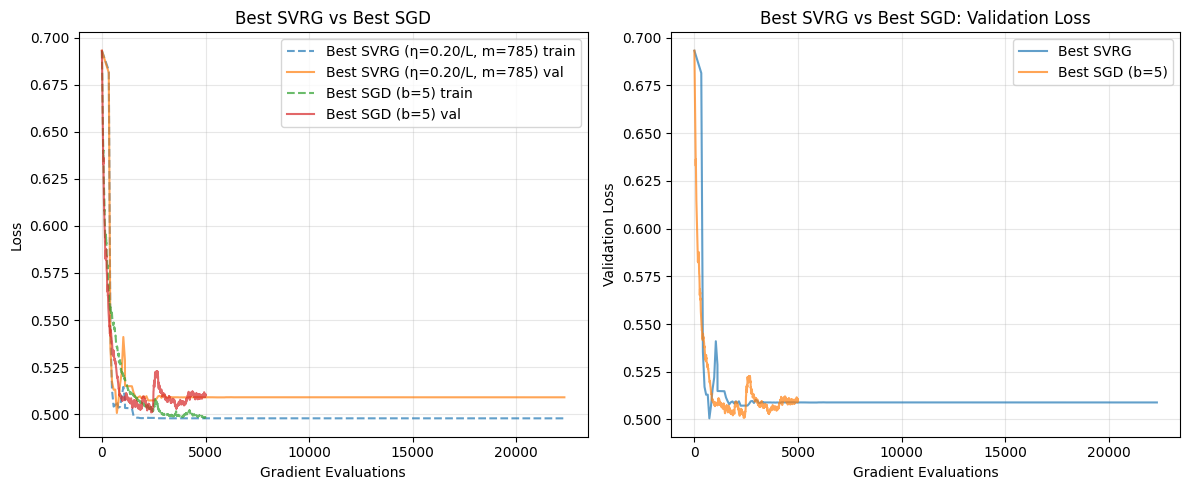


Best SVRG: η=0.20/L, m=785
  Final validation loss: 0.508924

Best SGD: batch size = 5
  Final validation loss: 0.509872


In [12]:
# Plot Part III results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Group by eta
for idx, eta in enumerate(eta_options):
    ax = axes[idx]
    for m in m_options:
        name = f'η={eta*L:.2f}/L, m={m}'
        if name in results_svrg:
            res = results_svrg[name]
            ax.plot(res['grad_evals'], res['train_loss'], 
                   label=f'm={m} (train)', linestyle='--', alpha=0.7)
            ax.plot(res['grad_evals'], res['val_loss'], 
                   label=f'm={m} (val)', alpha=0.7)
    ax.set_xlabel('Gradient Evaluations')
    ax.set_ylabel('Loss')
    ax.set_title(f'SVRG: η = {eta*L:.2f}/L')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/part3_svrg.png', dpi=150, bbox_inches='tight')
plt.show()

# Compare best SVRG with best SGD
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
# Find best SVRG (lowest final validation loss)
best_svrg_name = min(results_svrg.keys(), 
                     key=lambda k: results_svrg[k]['val_loss'][-1])
best_svrg = results_svrg[best_svrg_name]
plt.plot(best_svrg['grad_evals'], best_svrg['train_loss'], 
         label=f'Best SVRG ({best_svrg_name}) train', linestyle='--', alpha=0.7)
plt.plot(best_svrg['grad_evals'], best_svrg['val_loss'], 
         label=f'Best SVRG ({best_svrg_name}) val', alpha=0.7)

# Best SGD (from mini-batch experiments)
best_sgd_batch = min(results_minibatch.keys(), 
                    key=lambda k: results_minibatch[k]['val_loss'][-1])
best_sgd = results_minibatch[best_sgd_batch]
plt.plot(best_sgd['grad_evals'], best_sgd['train_loss'], 
         label=f'Best SGD (b={best_sgd_batch}) train', linestyle='--', alpha=0.7)
plt.plot(best_sgd['grad_evals'], best_sgd['val_loss'], 
         label=f'Best SGD (b={best_sgd_batch}) val', alpha=0.7)

plt.xlabel('Gradient Evaluations')
plt.ylabel('Loss')
plt.title('Best SVRG vs Best SGD')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(best_svrg['grad_evals'], best_svrg['val_loss'], 
         label=f'Best SVRG', alpha=0.7)
plt.plot(best_sgd['grad_evals'], best_sgd['val_loss'], 
         label=f'Best SGD (b={best_sgd_batch})', alpha=0.7)
plt.xlabel('Gradient Evaluations')
plt.ylabel('Validation Loss')
plt.title('Best SVRG vs Best SGD: Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/part3_svrg_vs_sgd.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nBest SVRG: {best_svrg_name}")
print(f"  Final validation loss: {best_svrg['val_loss'][-1]:.6f}")
print(f"\nBest SGD: batch size = {best_sgd_batch}")
print(f"  Final validation loss: {best_sgd['val_loss'][-1]:.6f}")


### Part III: Log-Scale Convergence Check (Linear Rate Diagnostic)


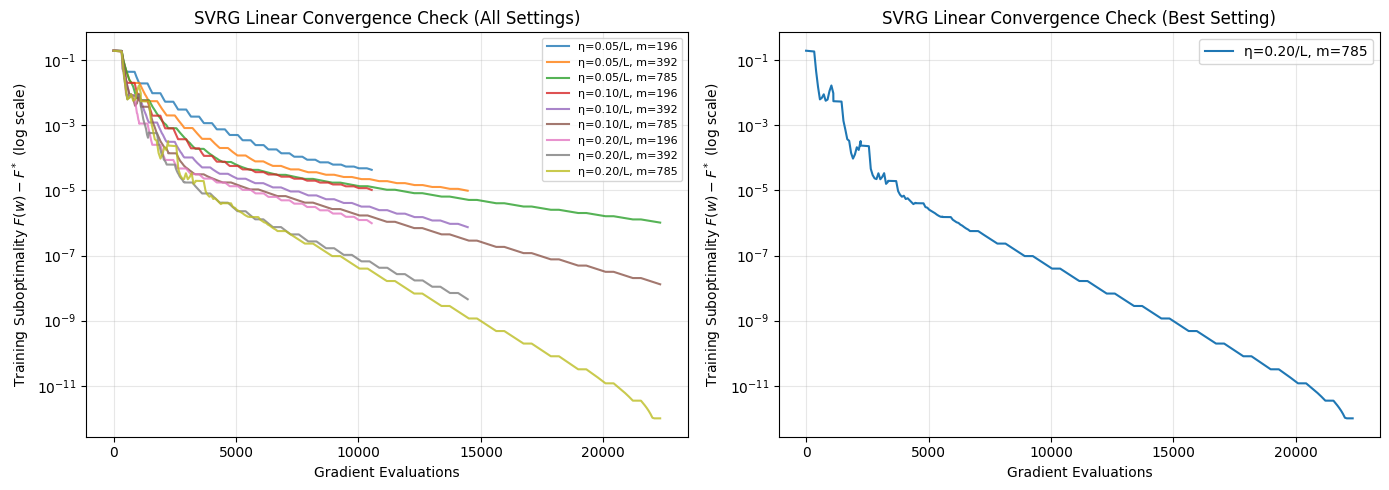

Estimated F*: 0.49774114
Best-by-training-final setting: η=0.20/L, m=785
If curves are approximately straight lines on this semilogy plot, it indicates linear convergence.


In [13]:
# Log-scale plot to diagnose linear convergence
# For linear convergence, log(F(w)-F*) should look approximately linear.

# Estimate F* from the best observed training loss across all SVRG trajectories
all_train_losses = np.concatenate([res['train_loss'] for res in results_svrg.values()])
F_star_est = np.min(all_train_losses)

# Numerical floor to avoid log(0)
eps = 1e-12

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (Left) Semilogy of suboptimality for all settings
ax = axes[0]
for name, res in results_svrg.items():
    subopt = np.maximum(res['train_loss'] - F_star_est, eps)
    ax.semilogy(res['grad_evals'], subopt, label=name, alpha=0.8)
ax.set_xlabel('Gradient Evaluations')
ax.set_ylabel(r'Training Suboptimality $F(w)-F^*$ (log scale)')
ax.set_title('SVRG Linear Convergence Check (All Settings)')
ax.legend(fontsize=8)
ax.grid(True, which='both', alpha=0.3)

# (Right) Best setting only (cleaner view)
best_train_name = min(results_svrg.keys(), key=lambda k: results_svrg[k]['train_loss'][-1])
best_train_res = results_svrg[best_train_name]
best_subopt = np.maximum(best_train_res['train_loss'] - F_star_est, eps)

ax = axes[1]
ax.semilogy(best_train_res['grad_evals'], best_subopt, label=best_train_name, color='tab:blue')
ax.set_xlabel('Gradient Evaluations')
ax.set_ylabel(r'Training Suboptimality $F(w)-F^*$ (log scale)')
ax.set_title('SVRG Linear Convergence Check (Best Setting)')
ax.legend()
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/part3_svrg_logscale_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Estimated F*: {F_star_est:.8f}")
print(f"Best-by-training-final setting: {best_train_name}")
print('If curves are approximately straight lines on this semilogy plot, it indicates linear convergence.')


### Part III: Fair Comparison Under Same Compute Budget


Best method per family under equal compute budget
--------------------------------------------------------------------------------------------------------------
  Budget | Best SGD (method / val)                       | Best SVRG (method / val)                     
--------------------------------------------------------------------------------------------------------------
    1000 | SGD b=5, used=1000, val=0.509052              | SVRG η=0.20/L, m=392, used=723, val=0.498809 
    2000 | SGD b=5, used=2000, val=0.508414              | SVRG η=0.05/L, m=392, used=1973, val=0.502329
    5000 | SGD b=5, used=5000, val=0.509872              | SVRG η=0.05/L, m=196, used=4743, val=0.505656
   10000 | SGD b=5, used=5000, val=0.509872              | SVRG η=0.05/L, m=196, used=9989, val=0.508828
--------------------------------------------------------------------------------------------------------------


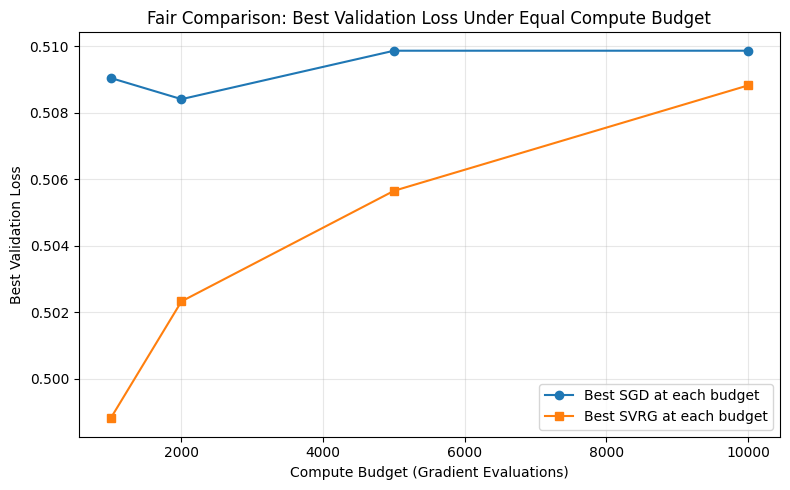

In [14]:
# Fair comparison under the same compute budget (gradient evaluations)

def value_at_budget(grad_evals, values, budget):
    """Return value at the largest index with grad_evals <= budget."""
    idx = np.searchsorted(grad_evals, budget, side='right') - 1
    idx = max(0, min(idx, len(values) - 1))
    return values[idx], int(grad_evals[idx])

# Budgets to compare
budgets = [1000, 2000, 5000, 10000]

# Build summary table: best SGD and best SVRG at each budget
summary_rows = []
for B in budgets:
    # SGD candidates
    sgd_candidates = []
    for b, res in results_minibatch.items():
        tr, used = value_at_budget(res['grad_evals'], res['train_loss'], B)
        va, _ = value_at_budget(res['grad_evals'], res['val_loss'], B)
        sgd_candidates.append((f'SGD b={b}', used, tr, va))
    best_sgd_B = min(sgd_candidates, key=lambda x: x[3])

    # SVRG candidates
    svrg_candidates = []
    for name, res in results_svrg.items():
        tr, used = value_at_budget(res['grad_evals'], res['train_loss'], B)
        va, _ = value_at_budget(res['grad_evals'], res['val_loss'], B)
        svrg_candidates.append((f'SVRG {name}', used, tr, va))
    best_svrg_B = min(svrg_candidates, key=lambda x: x[3])

    summary_rows.append((B, best_sgd_B, best_svrg_B))

# Print comparison table
print('Best method per family under equal compute budget')
print('-' * 110)
print(f"{'Budget':>8} | {'Best SGD (method / val)':<45} | {'Best SVRG (method / val)':<45}")
print('-' * 110)
for B, sgd_row, svrg_row in summary_rows:
    sgd_method, sgd_used, sgd_tr, sgd_va = sgd_row
    svrg_method, svrg_used, svrg_tr, svrg_va = svrg_row
    sgd_text = f"{sgd_method}, used={sgd_used}, val={sgd_va:.6f}"
    svrg_text = f"{svrg_method}, used={svrg_used}, val={svrg_va:.6f}"
    print(f"{B:8d} | {sgd_text:<45} | {svrg_text:<45}")
print('-' * 110)

# Plot best validation loss vs budget for SGD and SVRG
budget_vals = [row[0] for row in summary_rows]
best_sgd_vals = [row[1][3] for row in summary_rows]
best_svrg_vals = [row[2][3] for row in summary_rows]

plt.figure(figsize=(8, 5))
plt.plot(budget_vals, best_sgd_vals, marker='o', label='Best SGD at each budget')
plt.plot(budget_vals, best_svrg_vals, marker='s', label='Best SVRG at each budget')
plt.xlabel('Compute Budget (Gradient Evaluations)')
plt.ylabel('Best Validation Loss')
plt.title('Fair Comparison: Best Validation Loss Under Equal Compute Budget')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/part3_equal_budget_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
